In [79]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iriscsv/Iris.csv


In [80]:
df = pd.read_csv('/kaggle/input/iriscsv/Iris.csv')
df = df.iloc[:,1:]

In [81]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [82]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [83]:
df['Species'] = encoder.fit_transform(df['Species'])

In [84]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [85]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [86]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

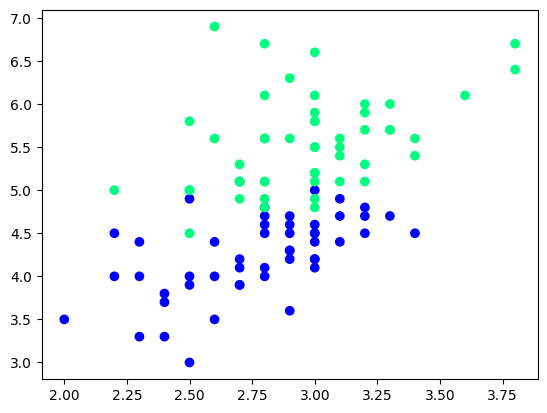

In [88]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'] , c = df['Species'],cmap='winter')

In [89]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
52,3.1,4.9,1
92,2.6,4.0,1
103,2.9,5.6,2
57,2.4,3.3,1
82,2.7,3.9,1
77,3.0,5.0,1
65,3.1,4.4,1
88,3.0,4.1,1
83,2.7,5.1,1
105,3.0,6.6,2


In [90]:
# Taking only 10 Rows for tarining
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [91]:
df_train

,SepalWidthCm,PetalLengthCm,Species
109,3.6,6.1,2
112,3.0,5.5,2
56,3.3,4.7,1
124,3.3,5.7,2
113,2.5,5.0,2
121,2.8,4.9,2
67,2.7,4.1,1
129,3.0,5.8,2
78,2.9,4.5,1
136,3.4,5.6,2


In [92]:
df_val

,SepalWidthCm,PetalLengthCm,Species
119,2.2,5.0,2
87,2.3,4.4,1
79,2.6,3.5,1
99,2.8,4.1,1
57,2.4,3.3,1


In [93]:
df_test

,SepalWidthCm,PetalLengthCm,Species
81,2.4,3.7,1
100,3.3,6.0,2
145,3.0,5.2,2
92,2.6,4.0,1
69,2.5,3.9,1


In [94]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [95]:
y_test

array([2, 1, 1, 1, 1])

In [96]:
X_test

array([[2.2, 5. ],
       [2.3, 4.4],
       [2.6, 3.5],
       [2.8, 4.1],
       [2.4, 3.3]])

**Case 1 - Bagging**

In [97]:
# Data for Tree 1
df_bag = df_train.sample(8)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
113,2.5,5.0,2
67,2.7,4.1,1
109,3.6,6.1,2
112,3.0,5.5,2
78,2.9,4.5,1
56,3.3,4.7,1
124,3.3,5.7,2
129,3.0,5.8,2


In [98]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [99]:
dt_bag1 = DecisionTreeClassifier()


In [100]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values , y.values , clf=clf,legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

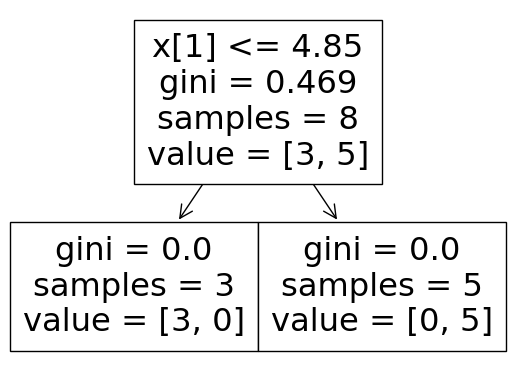

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


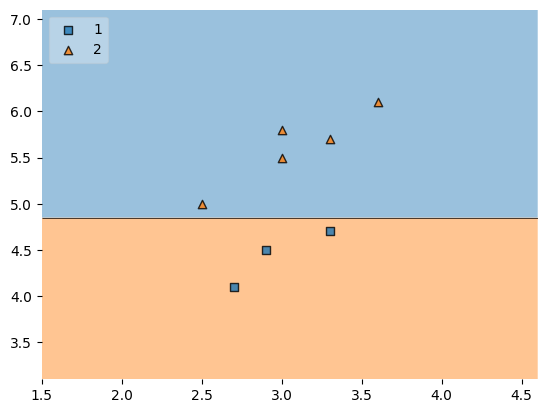

In [101]:
evaluate(dt_bag1,X,y)

In [102]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
124,3.3,5.7,2
129,3.0,5.8,2
109,3.6,6.1,2
112,3.0,5.5,2
113,2.5,5.0,2
67,2.7,4.1,1
78,2.9,4.5,1
78,2.9,4.5,1


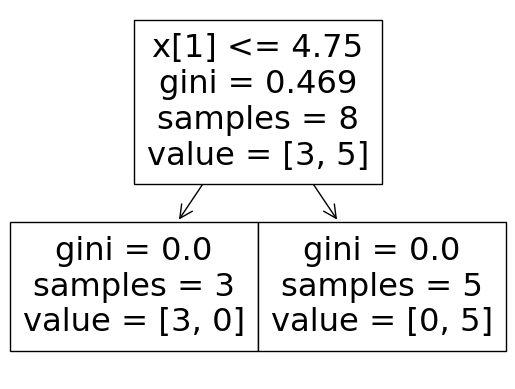

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


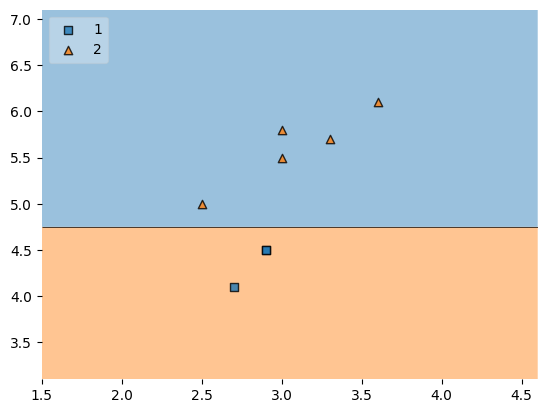

In [103]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [104]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)
# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
112,3.0,5.5,2
124,3.3,5.7,2
113,2.5,5.0,2
136,3.4,5.6,2
78,2.9,4.5,1
109,3.6,6.1,2
136,3.4,5.6,2
56,3.3,4.7,1


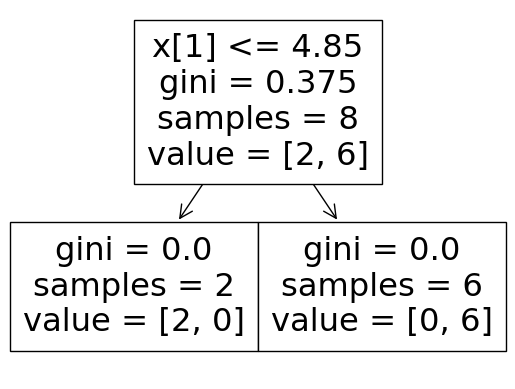

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


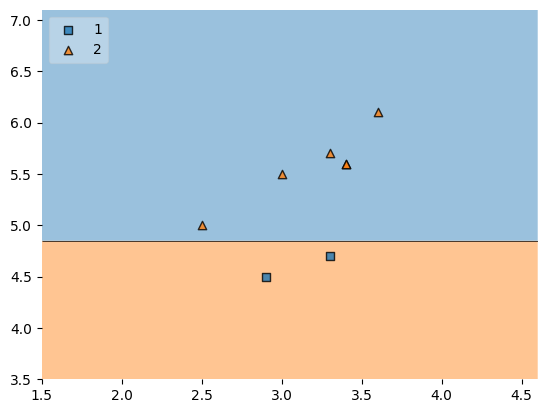

In [105]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

**Predict**

In [106]:
df_test

,SepalWidthCm,PetalLengthCm,Species
81,2.4,3.7,1
100,3.3,6.0,2
145,3.0,5.2,2
92,2.6,4.0,1
69,2.5,3.9,1


In [107]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


**Pasting**

In [108]:
# Row Sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
109,3.6,6.1,2
112,3.0,5.5,2
56,3.3,4.7,1
124,3.3,5.7,2
113,2.5,5.0,2
121,2.8,4.9,2
67,2.7,4.1,1
129,3.0,5.8,2
78,2.9,4.5,1
136,3.4,5.6,2


In [110]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
112,3.0,5.5,2
121,2.8,4.9,2
56,3.3,4.7,1
124,3.3,5.7,2
136,3.4,5.6,2
113,2.5,5.0,2
67,2.7,4.1,1
109,3.6,6.1,2


**Random Subspaces**

In [113]:
df1 = pd.read_csv('/kaggle/input/iriscsv/Iris.csv')
df1 = df1.sample(10)

In [114]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
22,23,4.6,3.6,1.0,0.2,Iris-setosa
13,14,4.3,3.0,1.1,0.1,Iris-setosa
19,20,5.1,3.8,1.5,0.3,Iris-setosa
101,102,5.8,2.7,5.1,1.9,Iris-virginica
115,116,6.4,3.2,5.3,2.3,Iris-virginica
94,95,5.6,2.7,4.2,1.3,Iris-versicolor
6,7,4.6,3.4,1.4,0.3,Iris-setosa
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
87,88,6.3,2.3,4.4,1.3,Iris-versicolor
14,15,5.8,4.0,1.2,0.2,Iris-setosa


In [115]:
df1.sample(2,replace=True,axis=1)

,SepalLengthCm,PetalLengthCm
22,4.6,1.0
13,4.3,1.1
19,5.1,1.5
101,5.8,5.1
115,6.4,5.3
94,5.6,4.2
6,4.6,1.4
50,7.0,4.7
87,6.3,4.4
14,5.8,1.2


**Random Patches**

In [116]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
22,23,4.6,3.6,1.0,0.2,Iris-setosa
13,14,4.3,3.0,1.1,0.1,Iris-setosa
19,20,5.1,3.8,1.5,0.3,Iris-setosa
101,102,5.8,2.7,5.1,1.9,Iris-virginica
115,116,6.4,3.2,5.3,2.3,Iris-virginica
94,95,5.6,2.7,4.2,1.3,Iris-versicolor
6,7,4.6,3.4,1.4,0.3,Iris-setosa
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
87,88,6.3,2.3,4.4,1.3,Iris-versicolor
14,15,5.8,4.0,1.2,0.2,Iris-setosa


In [119]:
df1.sample(8,replace=True).sample(2,replace = True,axis=1)

,Id,SepalWidthCm
14,15,4.0
19,20,3.8
94,95,2.7
101,102,2.7
94,95,2.7
115,116,3.2
6,7,3.4
101,102,2.7
